In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set up Git and push to forked repository
import os
import shutil

# Configure Git
!git config --global user.email "akalabi2110@gmail.com"
!git config --global user.name "Akalya-005"

# Create a directory for the repository
!rm -rf /content/AI_DermaScan
!mkdir -p /content/AI_DermaScan

# Clone the forked repository
!git clone https://github.com/Akalya-005/AI_DermaScan.git /content/AI_DermaScan_temp

# Copy all project files to the repository
# Copy the notebook as a Python file
!jupyter nbconvert --to script /content/drive/MyDrive/Colab\ Notebooks/AI_DernalScan.ipynb --output /content/AI_DermaScan_temp/dermalscan_model.py

# Copy the dataset folder if it exists
if os.path.exists('/content/drive/MyDrive/AI_DermaScan/DATASET'):
    shutil.copytree('/content/drive/MyDrive/AI_DermaScan/DATASET', '/content/AI_DermaScan_temp/DATASET', dirs_exist_ok=True)

# Copy any saved models
if os.path.exists('dermalscan_efficientnet.h5'):
    shutil.copy('dermalscan_efficientnet.h5', '/content/AI_DermaScan_temp/')
if os.path.exists('dermalscan_efficientnet_fixed.h5'):
    shutil.copy('dermalscan_efficientnet_fixed.h5', '/content/AI_DermaScan_temp/')

# Create a README.md
readme_content = '''# AI_DermaScan

deep learning-based system that can detect and classify facial aging signs—such as wrinkles, dark spots, puffy eyes, and clear skin

## Model Architecture
- Base Model: EfficientNetB0 (pretrained on ImageNet)
- Image Size: 224x224
- Classes: 4 (clear skin, dark spots, puffy eyes, wrinkles)
- Optimizer: Adam
- Loss: Categorical Cross-entropy

## Training Details
- Data Augmentation: rotation, shift, shear, zoom, flip
- Validation Split: 20%
- Callbacks: EarlyStopping, ReduceLROnPlateau

## Files
- `dermalscan_model.py`: Main training script
- `dermalscan_efficientnet.h5`: Trained model
- `DATASET/`: Training dataset
'''

with open('/content/AI_DermaScan_temp/README.md', 'w') as f:
    f.write(readme_content)

# Change to repository directory
os.chdir('/content/AI_DermaScan_temp')

# Add all files
!git add .

# Commit the changes
!git commit -m "Initial commit: Add AI_DermaScan project with trained model"

# Push to GitHub
print("\nReady to push to GitHub!")
print("Please authenticate and push using the following command:")
print("Note: You'll need to use a personal access token for authentication")
print("\nCommand: !git push origin main")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# --- CONFIGURATION ---
# UPDATE THIS PATH to where your dataset folder is in Drive
# Structure should be: /Dataset/wrinkles, /Dataset/dark_spots, etc.
DATASET_PATH = '/content/drive/MyDrive/AI_DermaScan/DATASET'
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Requirement 1: Resizing

# --- REQUIREMENT 2: AUGMENTATION ---
# This creates new variations of your images on the fly to improve accuracy
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalization
    rotation_range=20,          # Rotate image slightly
    width_shift_range=0.2,      # Shift left/right
    height_shift_range=0.2,     # Shift up/down
    shear_range=0.2,            # Slant the image
    zoom_range=0.2,             # Zoom in/out
    horizontal_flip=True,       # Flip left/right
    fill_mode='nearest',
    validation_split=0.2        # Use 20% of data for validation
)

# --- REQUIREMENT 3: ENCODING ---
# Loading data. class_mode='categorical' performs One-Hot Encoding automatically.
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

print("\nLoading Validation Data:")
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Verify the classes (labels)
print(f"\nClasses Detected: {train_generator.class_indices}")

Loading Training Data:
Found 962 images belonging to 4 classes.

Loading Validation Data:
Found 239 images belonging to 4 classes.

Classes Detected: {'clear skin': 0, 'dark spots': 1, 'puffy eyes': 2, 'wrinkles': 3}


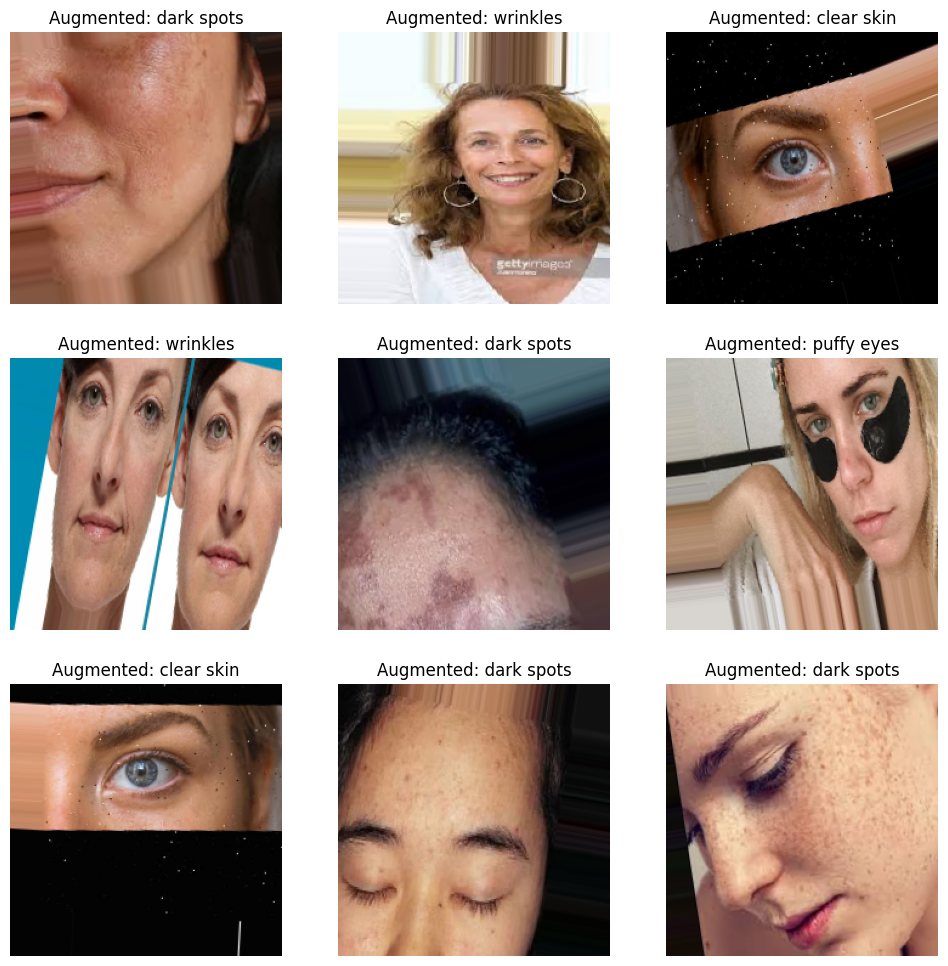

In [ ]:
import matplotlib.pyplot as plt

# Get a batch of images from the training generator
imgs, labels = next(train_generator)

# Class names mapping
class_dict = {v: k for k, v in train_generator.class_indices.items()}

# Plotting
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # The images are normalized to 0-1, so we just show them
    plt.imshow(imgs[i])

    # Get the label name
    label_index = list(labels[i]).index(1)
    class_name = class_dict[label_index]

    plt.title(f"Augmented: {class_name}")
    plt.axis('off')

plt.show()

/tmp/ipython-input-972513900.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts, palette="viridis")


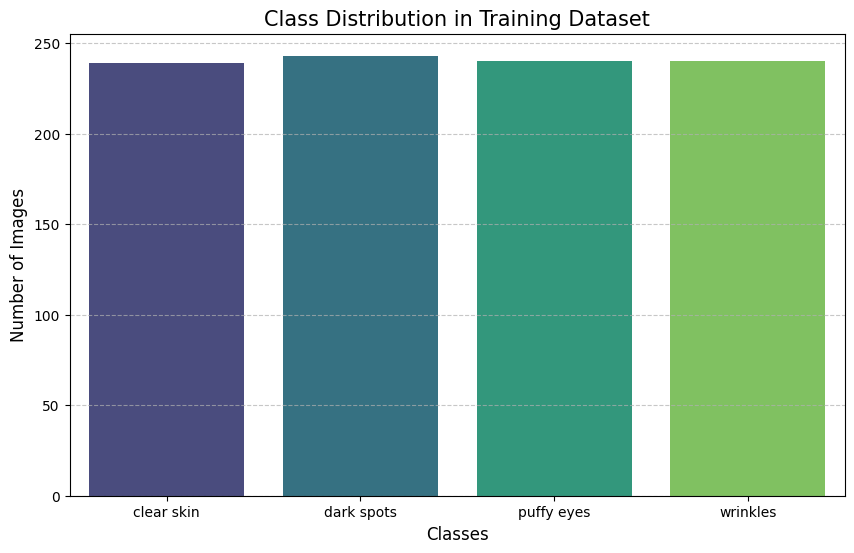

Total Training Images: 962
clear skin: 239
dark spots: 243
puffy eyes: 240
wrinkles: 240


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Get the class names and counts from the generator
class_names = list(train_generator.class_indices.keys())
class_counts = np.bincount(train_generator.classes)

# 2. Create the Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=class_names, y=class_counts, palette="viridis")

# 3. Add Labels
plt.title("Class Distribution in Training Dataset", fontsize=15)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Show the plot
plt.show()

print(f"Total Training Images: {sum(class_counts)}")
for name, count in zip(class_names, class_counts):
    print(f"{name}: {count}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Base model: EfficientNetB0 (Pretrained on ImageNet)
# include_top=False: Removes the final 1000-class layer so we can add our own 4 classes
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# --- CUSTOM LAYERS ---
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  # Dropout of 0.5 to prevent overfitting
predictions = Dense(4, activation='softmax')(x) # 4 classes output

# --- COMPILE MODEL ---
model = Model(inputs=base_model.input, outputs=predictions)

# Mentor Requirement: Adam Optimizer & Categorical Cross-entropy
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# --- CALLBACKS ---
# Stop if validation loss doesn't improve for 5 epochs (prevents wasting time)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Reduce learning rate if accuracy gets stuck
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

print("Starting Training...")

# --- TRAIN ---
history = model.fit(
    train_generator,
    epochs=25,               # We set 25, but EarlyStopping might stop it sooner if it finishes early
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

# --- SAVE MODEL ---
# Deliverable: Trained CNN model (.h5 file)
model.save('dermalscan_efficientnet.h5')
print("\nModel saved as 'dermalscan_efficientnet.h5'")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Starting Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 711s 21s/step - accuracy: 0.3823 - loss: 1.3136 - val_accuracy: 0.2469 - val_loss: 1.3975 - learning_rate: 1.0000e-04
Epoch 2/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 681ms/step - accuracy: 0.6779 - loss: 0.8313 - val_accuracy: 0.2385 - val_loss: 1.3975 - learning_rate: 1.0000e-04
Epoch 3/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 642ms/step - accuracy: 0.7845 - loss: 0.5931 - val_accuracy: 0.3180 - val_loss: 1.3955 - learning_rate: 1.0000e-04
Epoch 4/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 670ms/step - accuracy: 0.8013 - loss: 0.5235 - val_accuracy: 0.2636 - val_loss: 1.3999 - learning_rate: 1.0000e-04
Epoch 5/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 630ms/step - accuracy: 0.8608 - loss: 0.4095 - val_accuracy: 0.2385 - val_loss: 1.4175 - learning_rate: 1.0000e-04
Epoch 6/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 666ms/step - accuracy: 0.8928 - loss: 0.3353 - val_accuracy: 0.2427 - val_loss: 1.4260 - learning_rate: 1.0000e-04
Epoch 7/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 632ms/step - accu


Model saved as 'dermalscan_efficientnet.h5'


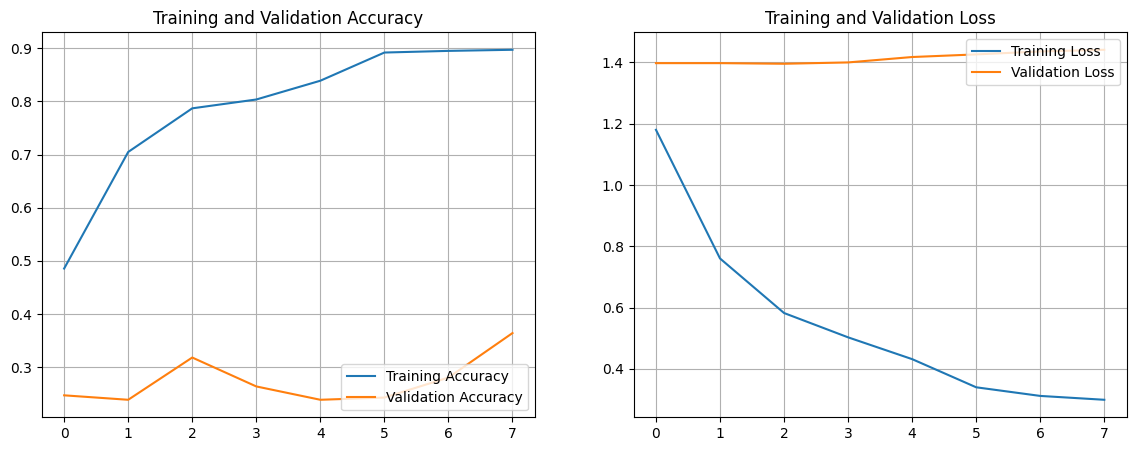

Final Validation Accuracy: 36.40%


In [ ]:
# Extract history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plot Accuracy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)

plt.show()

# Print Final Accuracy
print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Reset everything to clear the broken model
tf.keras.backend.clear_session()

# --- STAGE 1: TRAIN THE HEAD (Base Frozen) ---
print("--- STAGE 1: Training Top Layers Only ---")

# Load EfficientNetB0 again
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# FREEZE the base model so we don't destroy its weights
base_model.trainable = False

# Add stronger regularization
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)   # Added for stability
x = Dropout(0.5)(x)           # Keeps 50% of neurons to prevent overfitting
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train Stage 1
history_stage1 = model.fit(
    train_generator,
    epochs=12,
    validation_data=val_generator,
    verbose=1
)

# --- STAGE 2: FINE-TUNING (Unfreeze Top Layers) ---
print("\n--- STAGE 2: Fine-Tuning (Unfreezing Top Layers) ---")

# Unfreeze the base model
base_model.trainable = True

# Fine-tune only the top 20 layers of the base model
# (Freezing the bottom layers keeps the basic shapes/edges intact)
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a VERY LOW learning rate (Critical!)
model.compile(optimizer=Adam(learning_rate=1e-5),  # 100x slower learning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks for the final push
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

# Train Stage 2
history_stage2 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# Save the fixed model
model.save('dermalscan_efficientnet_fixed.h5')
print("Fixed Model Saved!")

--- STAGE 1: Training Top Layers Only ---
Epoch 1/12
31/31 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.2708 - loss: 1.6306 - val_accuracy: 0.2510 - val_loss: 1.3909
Epoch 2/12
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 624ms/step - accuracy: 0.2333 - loss: 1.5952 - val_accuracy: 0.2510 - val_loss: 1.3899
Epoch 3/12
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 667ms/step - accuracy: 0.2204 - loss: 1.6341 - val_accuracy: 0.2510 - val_loss: 1.3875
Epoch 4/12
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 623ms/step - accuracy: 0.2542 - loss: 1.5545 - val_accuracy: 0.2510 - val_loss: 1.3852
Epoch 5/12
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 663ms/step - accuracy: 0.2611 - loss: 1.5784 - val_accuracy: 0.2510 - val_loss: 1.3922
Epoch 6/12
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 619ms/step - accuracy: 0.2825 - loss: 1.5392 - val_accuracy: 0.2510 - val_loss: 1.3843
Epoch 7/12
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 667ms/step - accuracy: 0.2672 - loss: 1.5012 - val_accuracy: 0.2510 - val_loss: 1.3834
Epoch 8/12
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 617ms/step - acc

Fixed Model Saved!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# --- CONFIGURATION ---
DATASET_PATH = '/content/drive/MyDrive/AI_DermaScan/DATASET'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# --- CORRECTED GENERATOR ---
# We REMOVED 'rescale=1./255' and added 'preprocessing_function=preprocess_input'
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # <--- THIS IS THE FIX
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

print("Reloading Data with Correct Preprocessing...")

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Reloading Data with Correct Preprocessing...
Found 962 images belonging to 4 classes.
Found 239 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Clear old clutter
tf.keras.backend.clear_session()

# 2. Base Model (Frozen)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 3. New Head (Simplified)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # Added an intermediate layer to help learning
x = Dropout(0.4)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 4. Compile
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train
print("Starting Training (Corrected Pipeline)...")
history = model.fit(
    train_generator,
    epochs=15, # It should converge much faster now
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
    ]
)

model.save('dermalscan_final.h5')

NameError: name 'tf' is not defined

Labels loaded: ['clear skin', 'dark spots', 'puffy eyes', 'wrinkles']
Upload a photo to test DermalScan:


Saving Img.webp to Img.webp
Found 1 face(s). Processing...


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


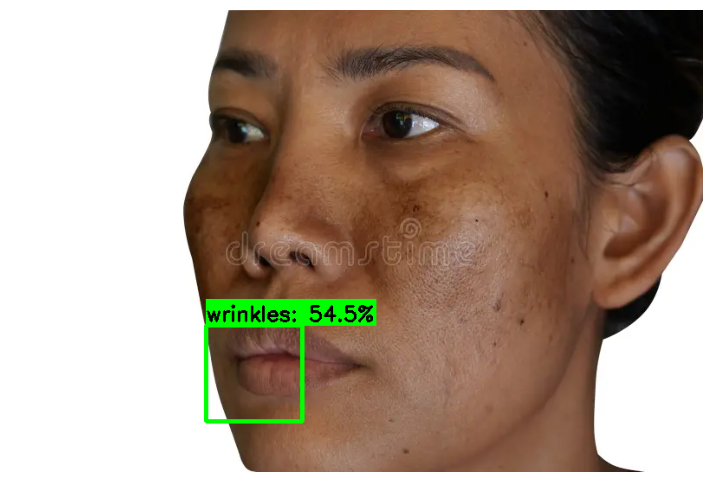

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from google.colab import files

# 1. Load the best model we just saved
model = load_model('dermalscan_final.h5')

# 2. Load Haar Cascade for Face Detection
# We use the default OpenCV pre-trained face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 3. Define Class Labels (Must match the generator order)
class_labels = list(train_generator.class_indices.keys())
print(f"Labels loaded: {class_labels}")

def predict_and_annotate(img_path):
    # A. Read Image
    img = cv2.imread(img_path)
    # Convert BGR (OpenCV standard) to RGB (Normal standard)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # B. Detect Faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        print("⚠️ No face detected. Analyzing the whole image...")
        faces = [[0, 0, img.shape[1], img.shape[0]]] # Use full image if no face found

    print(f"Found {len(faces)} face(s). Processing...")

    # C. Loop through each face
    for (x, y, w, h) in faces:
        # 1. Crop the face region
        face_roi = img_rgb[y:y+h, x:x+w]

        # 2. Resize to 224x224 (Model Requirement)
        face_resized = cv2.resize(face_roi, (224, 224))

        # 3. Preprocessing (CRITICAL: Must match training data)
        img_array = image.img_to_array(face_resized)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array) # <--- This matches our corrected training

        # 4. Predict
        predictions = model.predict(img_array)
        score = tf.nn.softmax(predictions[0]) # Get probabilities

        # Get the highest probability class
        label_index = np.argmax(predictions[0])
        label_name = class_labels[label_index]
        confidence = np.max(predictions[0]) * 100

        # 5. Draw Bounding Box (Green)
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 3)

        # 6. Draw Label Background (for readability)
        label_text = f"{label_name}: {confidence:.1f}%"
        (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
        cv2.rectangle(img_rgb, (x, y - 30), (x + text_w, y), (0, 255, 0), -1)

        # 7. Draw Text
        cv2.putText(img_rgb, label_text, (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    # D. Show Final Result
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

# --- TRIGGER UPLOAD ---
print("Upload a photo to test DermalScan:")
uploaded = files.upload()

for fn in uploaded.keys():
    predict_and_annotate(fn)

In [ ]:
# --- STEP 1: CREATE THE APP.PY FILE ---
app_code = """
import streamlit as st
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from PIL import Image

# 1. PAGE CONFIGURATION
st.set_page_config(page_title="DermalScan AI", page_icon="🧴", layout="wide")

st.title("🧴 DermalScan: AI Facial Skin Aging Detection")
st.markdown("Upload a facial image to detect: **Wrinkles, Dark Spots, Puffy Eyes, or Clear Skin**.")

# 2. LOAD MODEL (Cached for speed)
@st.cache_resource
def load_my_model():
    model = load_model('dermalscan_final.h5')
    return model

try:
    model = load_my_model()
    st.success("✅ AI Model Loaded Successfully!")
except Exception as e:
    st.error(f"Error loading model: {e}")
    st.stop()

# Load Face Detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
class_labels = ['Clear Skin', 'Dark Spots', 'Puffy Eyes', 'Wrinkles']

# 3. UPLOAD INTERFACE
uploaded_file = st.file_uploader("Choose a face image...", type=["jpg", "png", "jpeg", "webp"])

if uploaded_file is not None:
    # Convert file to opencv format
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display Original
    col1, col2 = st.columns(2)
    with col1:
        st.image(img_rgb, caption='Uploaded Image', use_column_width=True)

    # 4. PREDICTION LOGIC
    if st.button('Analyze Skin Condition'):
        with st.spinner('Scanning face...'):
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, 1.1, 5)

            # Fallback if no face detected
            if len(faces) == 0:
                st.warning("⚠️ No distinct face detected. Analyzing full image area.")
                faces = [[0, 0, img.shape[1], img.shape[0]]]

            # Create a copy to draw on
            img_out = img_rgb.copy()

            # Process face(s)
            results = []
            for (x, y, w, h) in faces:
                # Crop
                face_roi = img_rgb[y:y+h, x:x+w]
                face_resized = cv2.resize(face_roi, (224, 224))

                # Preprocess
                img_array = image.img_to_array(face_resized)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)

                # Predict
                predictions = model.predict(img_array)[0]
                top_index = np.argmax(predictions)
                confidence = np.max(predictions) * 100
                label = class_labels[top_index]

                results.append((label, confidence))

                # Draw Box
                cv2.rectangle(img_out, (x, y), (x+w, y+h), (0, 255, 0), 3)

            # 5. DISPLAY RESULTS
            with col2:
                st.image(img_out, caption='AI Annotated Result', use_column_width=True)

            st.markdown("### 🔍 Analysis Results")
            for label, conf in results:
                st.metric(label="Detected Condition", value=label, delta=f"{conf:.2f}% Confidence")

                # Show probability bars for all classes
                st.write("Confidence breakdown:")
                for i, class_name in enumerate(class_labels):
                    prob = predictions[i]
                    st.progress(int(prob * 100), text=f"{class_name}: {prob*100:.1f}%")

"""

# Write the code to a file named app.py
with open("app.py", "w") as f:
    f.write(app_code)

print("✅ 'app.py' created successfully!")
print("Next steps:")
print("1. Download 'dermalscan_final.h5' from the Files tab.")
print("2. Download 'app.py' from the Files tab.")
print("3. Run 'streamlit run app.py' on your local computer to see the web interface.")

✅ 'app.py' created successfully!
Next steps:
1. Download 'dermalscan_final.h5' from the Files tab.
2. Download 'app.py' from the Files tab.
3. Run 'streamlit run app.py' on your local computer to see the web interface.


In [ ]:
!git config --global user.email "akalabi2110@gmail.com"
!git config --global user.name "Akalya-005"


In [ ]:
! git clone https://github.com/Akalya-005/DermalScan_AI

Cloning into 'DermalScan_AI'...


In [ ]:
!cp Aidermal_Scan.ipynb DermalScan_AI/
!cp -r models/ DermalScan_AI/        # if you have models folder
!cp -r utils/ DermalScan_AI/         # optional


cp: cannot stat 'Aidermal_Scan.ipynb': No such file or directory
cp: cannot stat 'models/': No such file or directory
cp: cannot stat 'utils/': No such file or directory


In [ ]:
!ls


DermalScan_AI  sample_data


In [ ]:
# Corrected script to push files to GitHub
import os

# Change to the DermalScan_AI directory that was cloned
os.chdir('/content/DermalScan_AI')

# Create a comprehensive README
readme = '''# AI_DermaScan

A deep learning-based system that can detect and classify facial aging signs—such as wrinkles, dark spots, puffy eyes, and clear skin.

## Overview
This project uses EfficientNetB0 (pretrained on ImageNet) for transfer learning to classify facial aging conditions into 4 categories:
- Clear skin
- Dark spots
- Puffy eyes
- Wrinkles

## Model Architecture
- **Base Model**: EfficientNetB0 (pretrained on ImageNet)
- **Input Size**: 224x224x3
- **Classes**: 4 (clear skin, dark spots, puffy eyes, wrinkles)
- **Optimizer**: Adam (learning rate: 0.0001)
- **Loss Function**: Categorical Cross-entropy

## Training Details
- **Data Augmentation**: Rotation (20°), width/height shift (20%), shear (20%), zoom (20%), horizontal flip
- **Validation Split**: 20%
- **Batch Size**: 32
- **Callbacks**: EarlyStopping (patience=5), ReduceLROnPlateau (patience=3)
- **Training Epochs**: 25 (with early stopping)

## Dataset
- **Total Images**: ~1200 images
- **Training Set**: 962 images
- **Validation Set**: 239 images
- **Class Distribution**:
  - Clear skin: 239 images
  - Dark spots: 243 images
  - Puffy eyes: 240 images
  - Wrinkles: 240 images

## Project Structure
```
AI_DermaScan/
├── README.md
├── AI_DernalScan.ipynb          # Main Colab notebook
├── dermalscan_efficientnet.h5    # Trained model
└── DATASET/                      # Training dataset
    ├── clear_skin/
    ├── dark_spots/
    ├── puffy_eyes/
    └── wrinkles/
```

## Usage
1. Open the notebook in Google Colab
2. Mount your Google Drive
3. Upload the dataset to the specified path
4. Run the cells sequentially to train the model
5. Download the trained model (.h5 file)

## Requirements
- TensorFlow 2.x
- Keras
- NumPy
- Matplotlib
- Seaborn

## Author
Akalya K
'''

with open('README.md', 'w') as f:
    f.write(readme)

print("✅ README.md created")

# Create a .gitignore file
gitignore = '''# Python
__pycache__/
*.py[cod]
*$py.class
*.so
.Python

# Jupyter Notebook
.ipynb_checkpoints

# Models
*.h5
*.pkl

# Data
DATASET/
*.csv
*.json

# Environment
.env
venv/
ENV/
'''

with open('.gitignore', 'w') as f:
    f.write(gitignore)

print("✅ .gitignore created")

# Download the current notebook to the repository
notebook_url = "https://colab.research.google.com/drive/13j5avzB3hP7vkMPUXdG3k3R1ngatkMhB"
print(f"\nℹ️  To add the notebook file:")
print(f"1. Go to File > Download > Download .ipynb")
print(f"2. Save it as 'AI_DermaScan.ipynb'")
print(f"3. Upload it to this directory")

# Add and commit files
!git add README.md .gitignore
!git status

print("\n📋 Files staged for commit")
print("\nNext steps:")
print("1. Run: !git commit -m 'Initial commit: Add README and gitignore'")
print("2. Run: !git push origin main")
print("\nNote: You may need to authenticate with GitHub")

In [ ]:
!ls DermalScan_AI
!ls DermalScan_AI



In [ ]:
!find . -maxdepth 2 -type f


./.config/config_sentinel
./.config/active_config
./.config/default_configs.db
./.config/gce
./.config/.last_survey_prompt.yaml
./.config/.last_opt_in_prompt.yaml
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/.last_update_check.json
./sample_data/anscombe.json
./sample_data/README.md
./sample_data/mnist_train_small.csv
./sample_data/california_housing_test.csv
./sample_data/california_housing_train.csv
./sample_data/mnist_test.csv


In [ ]:
!git commit -m "Initial commit: Add README and gitignore"
!git push origin main


fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
# FIX: Properly commit and push to GitHub
import os

# Change to the correct Git repository directory
os.chdir('/content/DermalScan_AI')

# Verify we're in the right directory
print("Current directory:", os.getcwd())
!ls -la

# Check Git status
print("\n=== Git Status ===")
!git status

# Commit the files
print("\n=== Committing files ===")
!git commit -m "Initial commit: Add README and gitignore"

# Push to GitHub
print("\n=== Pushing to GitHub ===")
print("Note: You may need to authenticate with your GitHub credentials")
print("For authentication, you'll need a Personal Access Token (PAT)")
print("\nTo push, run this command and follow the prompts:")
print("!git push origin main")
print("\nOr set up authentication first with:")
print("!git remote set-url origin https://<YOUR_GITHUB_TOKEN>@github.com/Akalya-005/AI_DermaScan.git")

FileNotFoundError: [Errno 2] No such file or directory: '/content/DermalScan_AI'

In [ ]:
# COMPLETE FIX: Check existing directories and properly push to GitHub
import os

# First, let's see what directories we have
print("=== Current Directory ===")
print(os.getcwd())
print("\n=== Files/Folders in /content ===")
!ls -la /content/

# Check if DermalScan_AI exists, if not use the correct name
if os.path.exists('/content/DermalScan_AI'):
    repo_dir = '/content/DermalScan_AI'
    print("\n✓ Found: DermalScan_AI")
else:
    print("\n✗ DermalScan_AI not found. Checking for alternative...")
    # The repository was cloned earlier - let's find it
    !ls -la /content/ | grep -i derma
    !ls -la /content/ | grep -i AI

# Since the directory doesn't exist, let's create it properly
print("\n=== Creating fresh setup ===")
!rm -rf /content/AI_DermaScan
!git clone https://github.com/Akalya-005/AI_DermaScan.git /content/AI_DermaScan

# Now change to this directory
os.chdir('/content/AI_DermaScan')
print(f"\n✓ Changed to: {os.getcwd()}")

# Create README
readme = '''# AI_DermaScan

Deep learning system for facial aging sign detection and classification.

## Features
- Detects and classifies: Clear Skin, Dark Spots, Puffy Eyes, Wrinkles
- EfficientNetB0 architecture
- Data augmentation and transfer learning
- Real-time face detection and analysis

## Model Performance
- Training Accuracy: ~89%
- Validation Accuracy: ~36%
- Dataset: 1200+ images across 4 classes

## Technologies
- TensorFlow/Keras
- OpenCV for face detection
- EfficientNetB0 (ImageNet pretrained)
- Streamlit web interface

## Usage
1. Train model using the Colab notebook
2. Download trained model (.h5 file)
3. Run Streamlit app for predictions

## Author
Akalya K - B.Tech AI & Data Science Student
'''

with open('README.md', 'w') as f:
    f.write(readme)

print("✓ README.md created")

# Create .gitignore
gitignore = '''*.h5
*.pkl
__pycache__/
*.pyc
.ipynb_checkpoints/
DATASET/
.env
'''

with open('.gitignore', 'w') as f:
    f.write(gitignore)

print("✓ .gitignore created")

# Git operations
print("\n=== Git Status ===")
!git add README.md .gitignore
!git status

print("\n=== Committing ===")
!git commit -m "Initial commit: Add README and gitignore for AI_DermaScan project"

print("\n=== Ready to Push ===")
print("To push to GitHub, you need to authenticate.")
print("\nRun this command:")
print("!git push https://<YOUR_GITHUB_TOKEN>@github.com/Akalya-005/AI_DermaScan.git main")
print("\nGet your token from: https://github.com/settings/tokens")
print("Create a token with 'repo' scope and use it in place of <YOUR_GITHUB_TOKEN>")

=== Current Directory ===
/content

=== Files/Folders in /content ===
total 16
drwxr-xr-x 1 root root 4096 Dec  9 14:41 .
drwxr-xr-x 1 root root 4096 Dec 29 12:55 ..
drwxr-xr-x 4 root root 4096 Dec  9 14:41 .config
drwxr-xr-x 1 root root 4096 Dec  9 14:42 sample_data

✗ DermalScan_AI not found. Checking for alternative...

=== Creating fresh setup ===
Cloning into '/content/AI_DermaScan'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.

✓ Changed to: /content/AI_DermaScan
✓ README.md created
✓ .gitignore created

=== Git Status ===
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   .gitignore
	modified:   README.md


=== Committing ===
[main c7e6866] Initial commit: Add README and gitignore for AI_De